# DIFNO forward surrogates (ice -> SSH)

Two trained forward operators: the default one, fitted on the `single` + `multi` ensembles,
and the triple one that also sees the `coastal` ensemble. Both are frozen afterwards and
supply the cycle-consistency term for the inverse operators.

## 1. Default forward surrogate (single + multi)

Trains the tied-weight DSE-FNO to map a Greenland ice-thickness-change field onto the
sea-surface-height fingerprint at the scattered altimetry points. Training data are the
`single` and `multi` Gaussian-blob ensembles pooled (20k samples, 16k train / 4k test),
normalised SSH targets, plain L1 loss, no gradient surgery. Final test relative L1 is
0.26% at the last epoch (best epoch 0.2615%); this frozen model provides the cycle-
consistency term for the default inverse.

Source: `cloud_notebooks/no_smooth_512full_forward_fingerprint_FNO_dse.ipynb`.

In [ ]:
# Model / loss / gradient-surgery definitions live in src/ (they were defined
# inline in the first cells of the original cloud notebooks):
#   src/models.py       VFT (Vandermonde transform), SpectralConv2d_dse, FNO_dse
#   src/losses.py       AmplitudeWeightedLoss
#   src/grad_surgery.py PCGrad / CAGrad
#   src/utilities.py    count_params, percentage_difference (from the DSE repo)
#   src/adam.py         complex-capable Adam (from the DSE repo)
import copy
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset

from src import Adam, count_params, percentage_difference, print_params_by_module
from src.device import get_device
from src.models import FNO_dse, set_default_device


In [ ]:
from torch.utils.data import TensorDataset
    

def getDataloaders (configs):
    """
    Loads the required data for the Airfoil experiment and returns the train and test dataloaders.

    Returns:
        train_loader (torch.utils.data.DataLoader): train dataloader
        test_loader (torch.utils.data.DataLoader): test dataloader
    """
    paths = [configs['datapath'] + 'no_smooth/512gp_single_SSH_altimetry_full.pt',
             configs['datapath'] + 'no_smooth/512gp_multi_SSH_altimetry_full.pt',
             ]#configs['datapath'] + 'no_smooth/512gp_single_sinner_SSH_altimetry_full.pt'
    data_list = [torch.load(path_) for path_ in paths]

    inputs = torch.cat([data_["sample_sum"].float().unsqueeze(-1) for data_ in data_list], dim=0)  # [N_total, 1]
    outputs = torch.cat([data_["altimetry"].float().unsqueeze(-1) for data_ in data_list], dim=0)  # [N_total, M, 1]
    outputs = (outputs - outputs.mean())/(outputs.std()+1e-6)

    #random permutation
    num_total = inputs.shape[0]

    indices = torch.randperm(num_total)


    train_indices = indices[:configs['num_train']]
    test_indices = indices[configs['num_train']:configs['num_train'] + configs['num_test']]
    train_in = inputs[train_indices]
    train_out = outputs[train_indices]
    test_in = inputs[test_indices]
    test_out = outputs[test_indices]
    
    # train_in = inputs[:configs['num_train']]
    # train_out = outputs[:configs['num_train']]
    # test_in = inputs[-configs['num_test']:]
    # test_out = outputs[-configs['num_test']:]


    train_loader = torch.utils.data.DataLoader(TensorDataset(train_in, train_out), batch_size=configs['batch_size'], shuffle=True)
    test_loader = torch.utils.data.DataLoader(TensorDataset(test_in, test_out), batch_size=1, shuffle=False)

    point_data_path = configs['datapath']+'512scaled_display_coords_full.pt'
    point_data = torch.load(point_data_path)
    point_data_out = point_data["Dist"].float()
    point_data_in = point_data["Gr"].float()
    
    return train_loader, test_loader, point_data_in, point_data_out


In [ ]:
device = get_device()        # cuda on the cluster, mps/cpu on a laptop
set_default_device(device)   # the VFT matrices are built on this device


In [ ]:
configs = {
    'save_model':           True,
    'model':                'fno-dse',
    'experiment':           'fingerprint',
    'num_train':            16000,
    'num_test':             4000,
    'batch_size':           400, 
    'epochs':               501,
    'test_epochs':          10,

    'datapath':             "data/",  # Path to data!!!!!

    # Training specific parameters
    'learning_rate':        0.001,
    'scheduler_step':       100,
    'scheduler_gamma':      0.1,
    'weight_decay':         1e-4,                   # Weight decay
    'loss_fn':              'L1',                   # Loss function to use - L1, L2
    'loss_fn_test':         'L1',                   # Loss function to use - L1, L2
    'cycle_weight':         0.01,                    # Weight of cycle consistency loss
    # Model specific parameters
    'modes1':               20,                     # Number of x-modes to use in the Fourier layer
    'modes2':               20,                     # Number of y-modes to use in the Fourier layer
    'width':                32,                     # Number of channels in the convolutional layers
}

Model = FNO_dse
# for key in Model.configs:
#             configs.setdefault(key, Model.configs[key])
# NOTE: Some configs will have been overwritten by the defaults in Model.configs, hence we print here!
print(configs)

start_time = time.time()
print(f'Loading and processing data.')

train_loader, test_loader, configs['point_data_in'],configs['point_data_out'] = getDataloaders(configs)

configs['denormalizer'] = None if not hasattr(train_loader, "denormalizer") else train_loader.denormalizer

print(f'Processing finished in {time.time()-start_time:.2f}s.')


#######
# model
#######
# initialize model
model = Model(configs).to(device)

# TODO: Trainable parameters will now include IPHI parameters as well.
print(f"Number of trainable parameters: {count_params(model)}")
optimizer = Adam(model.parameters(), lr=configs['learning_rate'], weight_decay=configs['weight_decay'])
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=configs['scheduler_step'], gamma=configs['scheduler_gamma'])
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max = 100)
# Define the loss function
if configs['loss_fn'] == 'L1':
    loss_fn = torch.nn.L1Loss()
elif configs['loss_fn'] == 'L2':
    loss_fn = torch.nn.MSELoss('mean')
else:
    raise ValueError('Loss function not recognized.')
# Define the loss function
if configs['loss_fn_test'] == 'L1':
    loss_fn_test = torch.nn.L1Loss()
elif configs['loss_fn_test'] == 'L2':
    loss_fn_test = torch.nn.MSELoss('mean')
else:
    raise ValueError('Loss function test not recognized.')
# class L1WithMeanLoss(nn.Module):
#     def __init__(self, mean_weight=1.0):
#         super().__init__()
#         self.l1 = nn.L1Loss()
#         self.mean_weight = mean_weight

#     def forward(self, pred, target):
#         l1_loss = self.l1(pred, target)
#         mean_loss = torch.abs(pred.mean() - target.mean())
#         return l1_loss + self.mean_weight * mean_loss
# if configs['loss_fn'] == 'L1':
#     loss_fn = L1WithMeanLoss(mean_weight=1)
print_params_by_module(model)


{'save_model': True, 'model': 'fno-dse', 'experiment': 'fingerprint', 'num_train': 16000, 'num_test': 4000, 'batch_size': 400, 'epochs': 501, 'test_epochs': 10, 'datapath': 'data/', 'learning_rate': 0.001, 'scheduler_step': 100, 'scheduler_gamma': 0.1, 'weight_decay': 0.0001, 'loss_fn': 'L1', 'loss_fn_test': 'L1', 'cycle_weight': 0.01, 'modes1': 20, 'modes2': 20, 'width': 32}
Loading and processing data.
Processing finished in 0.95s.
Number of trainable parameters: 21950313
fc0.weight                               32
fc0.bias                                 32
conv0.weights1                           409600
conv0.weights2                           409600
w0.weight                                1024
w0.bias                                  32
proj_w0.0.weight                         21123936
proj_w0.0.bias                           4968
fc1.weight                               1024
fc1.bias                                 32
fc2.weight                               32
fc2.bias         

In [ ]:
import time
start_time = time.time()
##########
# training
##########
training_times = []
train_loss_hist = []
test_loss_hist = []
relative_error_hist = []
relative_median_error_hist = []

for epoch in range(configs['epochs']):
    start_train = time.time()
    train_loss = 0
    model.train()
    for inputs, targets in train_loader:
        batch_size = targets.shape[0]
        if isinstance(inputs, list):
            inputs = [x.to(device) for x in inputs]
        else:
            inputs = inputs.to(device)
        targets = targets.to(device)

        predictions = model(inputs)

        # Compute loss separate for complex numbers
        if predictions.is_complex():
            loss = (
                loss_fn(predictions.real.view(batch_size, -1), targets.real.view(batch_size, -1)) 
                + loss_fn(predictions.imag.view(batch_size, -1), targets.imag.view(batch_size, -1))
            )
        else:
            loss = loss_fn(predictions.view(batch_size, -1), targets.view(batch_size, -1))

        # For diffeomorphisms, additional loss term:
        if hasattr(model, "model_iphi") and ('iphi_loss_reg' in configs) and (configs['iphi_loss_reg'] > 0):
            samples_x = torch.rand(batch_size, targets.shape[1], 2).cuda() * 3 - 1 # TODO Hardcoded values, check if applies to all
            samples_xi = model.model_iphi(samples_x)
            loss += configs['iphi_loss_reg'] * loss_fn(samples_xi, samples_x)

        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= configs['num_train']
    stop_train = time.time()
    training_times.append(stop_train-start_train)

    scheduler.step()

    ### Only test every test_epochs epochs.
    if epoch % configs['test_epochs'] > 0:
        continue

    ##########
    # testing
    ##########
    with torch.no_grad():
        test_loss = 0
        relative_error = 0
        median_error = torch.zeros(configs['num_test'])

        model.eval()
        for idx, (inputs, targets) in enumerate(test_loader):
            batch_size = targets.shape[0]
            if isinstance(inputs, list):
                inputs = [x.to(device) for x in inputs]
            else:
                inputs = inputs.to(device)
            targets = targets.to(device)

            predictions = model(inputs)

            # # For different growth factors and sparse data in Humidity, we only consider a small domain.
            # if configs['experiment'] == 'Humidity' and configs['growth'] != 1.0:
            #     l, r, b, t = test_loader.crop
            #     predictions = predictions[:, b:t, l:r,:]
            #     targets = targets[:, b:t, l:r,:]

            # Compute loss separate for complex numbers
            if predictions.is_complex():
                loss = (
                    loss_fn_test(predictions.real.reshape(batch_size, -1), targets.real.reshape(batch_size, -1)) 
                    + loss_fn_test(predictions.imag.reshape(batch_size, -1), targets.imag.reshape(batch_size, -1))
                )
                # For metrics we only consider REAL parts
                predictions = predictions.real
                targets = targets.real
            else:
                loss = loss_fn_test(predictions.reshape(batch_size, -1), targets.reshape(batch_size, -1))
            test_loss += loss.item()

            relative_error += percentage_difference(targets.reshape(batch_size, -1), predictions.reshape(batch_size, -1))
            median_error[idx] = percentage_difference(targets.reshape(batch_size, -1), predictions.reshape(batch_size, -1))

    test_loss /= configs['num_test']
    relative_error /= configs['num_test']
    relative_error_hist.append(relative_error)
    relative_median_error_hist.append(torch.median(median_error))


    print(f"Epoch [{epoch:03d}/{configs['epochs']-1}] in {stop_train-start_train:.2f}s with LR {scheduler.get_last_lr()[0]:.2e}: \tTrain loss {train_loss:.4e} \t- Test loss {test_loss:.4e} \t- Test Error {relative_error:.2f}% \t- Median Test Error {torch.median(median_error).item():.4f}%")
    train_loss_hist.append(train_loss)
    test_loss_hist.append(test_loss)

    if relative_error == min(relative_error_hist):
        best_model = copy.deepcopy(model)


lowest_error = min(relative_error_hist)
# Plot losses
plt.figure(figsize=(8,6))
plt.plot([np.log(x) for x in train_loss_hist], label='Train loss')
plt.plot([np.log(x) for x in test_loss_hist], label='Test loss')
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.legend()
plt.grid()
# plt.savefig(f"_Models/loss_history.png")
plt.close()

# Save Model
if configs['save_model']:
    # Remove unnecessary data from models
    best_model.point_data = None
    best_model.denormalizer = None
    print(f"Experiment: {configs['experiment']} \t- Model: {configs['model']} \t- Error: {lowest_error:.4f}%")
    torch.save(best_model, f"_Models/{configs['experiment']}_{configs['model']}.pt")

np.savez("no_smooth_fullMLP512full_forward_fingerprint_FNO_dse_history.npz",
         training_times=training_times,
         train_loss_hist=train_loss_hist,
         test_loss_hist=test_loss_hist,
         relative_error_hist=relative_error_hist,
         relative_median_error_hist=relative_median_error_hist)
torch.save(best_model, f"_Models/no_smooth_512forward_full.pt")
print(f"time used {time.time()-start_time}")


Epoch [000/500] in 22.40s with LR 1.00e-03: 	Train loss 4.1379e-04 	- Test loss 3.3388e-02 	- Test Error 7.31% 	- Median Test Error 4.9970%
Epoch [010/500] in 11.26s with LR 1.00e-03: 	Train loss 5.2923e-05 	- Test loss 2.3649e-02 	- Test Error 4.81% 	- Median Test Error 3.6768%
Epoch [020/500] in 11.28s with LR 1.00e-03: 	Train loss 3.9108e-05 	- Test loss 1.7763e-02 	- Test Error 3.58% 	- Median Test Error 2.5636%
Epoch [030/500] in 11.30s with LR 1.00e-03: 	Train loss 4.8563e-05 	- Test loss 1.3332e-02 	- Test Error 3.03% 	- Median Test Error 1.9456%
Epoch [040/500] in 11.28s with LR 1.00e-03: 	Train loss 4.8924e-05 	- Test loss 1.8161e-02 	- Test Error 3.89% 	- Median Test Error 2.7045%
Epoch [050/500] in 11.28s with LR 1.00e-03: 	Train loss 4.1027e-05 	- Test loss 1.3541e-02 	- Test Error 3.40% 	- Median Test Error 2.0364%
Epoch [060/500] in 11.28s with LR 1.00e-03: 	Train loss 3.8021e-05 	- Test loss 1.9697e-02 	- Test Error 3.36% 	- Median Test Error 2.9069%
Epoch [070/500] in 1

Epoch [500/500] in 11.28s with LR 1.00e-08: 	Train loss 2.3706e-06 	- Test loss 1.1268e-03 	- Test Error 0.26% 	- Median Test Error 0.1613%


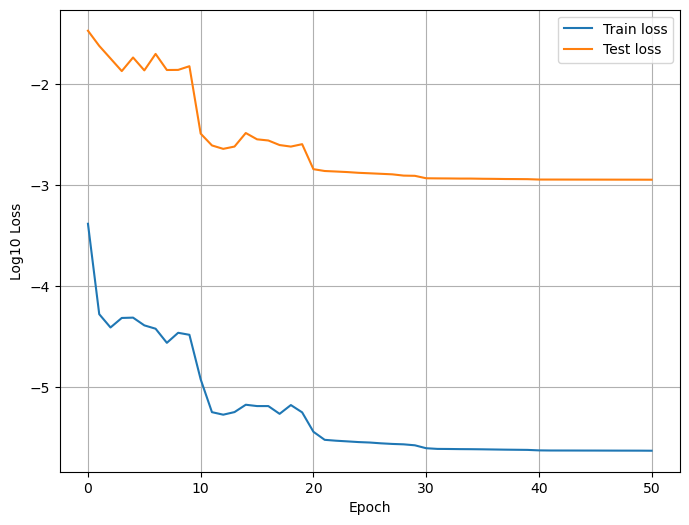

In [ ]:
print(f"Epoch [{epoch:03d}/{configs['epochs']-1}] in {stop_train-start_train:.2f}s with LR {scheduler.get_last_lr()[0]:.2e}: \tTrain loss {train_loss:.4e} \t- Test loss {test_loss:.4e} \t- Test Error {relative_error:.2f}% \t- Median Test Error {torch.median(median_error).item():.4f}%")

plt.figure(figsize=(8,6))
plt.plot([np.log10(x) for x in train_loss_hist], label='Train loss')
plt.plot([np.log10(x) for x in test_loss_hist], label='Test loss')
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.xlabel('Epoch')
plt.ylabel('Log10 Loss')
plt.legend()
plt.grid()


## 2. Triple forward surrogate (single + multi + coastal)

Same architecture, optimiser and schedule, but the pooled training set now also contains
the `coastal` (sinner) ensemble, so the surrogate stays accurate on coastal-concentrated
ice-loss patterns. Final test relative L1 is 0.38% pooled (best epoch 0.3790%; per-family
0.33 / 0.43 / 0.29% for single / multi / coastal). This model is the frozen forward
operator used by the coastal inverse.

Source: `cloud_notebooks/no_smooth_512full_tripledata_forward_fingerprint_FNO_dse-i1new.ipynb`.

In [ ]:
from torch.utils.data import TensorDataset
    

def getDataloaders (configs):
    """
    Loads the required data for the Airfoil experiment and returns the train and test dataloaders.

    Returns:
        train_loader (torch.utils.data.DataLoader): train dataloader
        test_loader (torch.utils.data.DataLoader): test dataloader
    """
    paths = [configs['datapath'] + 'no_smooth/512gp_single_SSH_altimetry_full.pt',
         configs['datapath'] + 'no_smooth/512gp_multi_SSH_altimetry_full.pt',
         configs['datapath'] + 'no_smooth/512gp_single_sinner_SSH_altimetry_full_i1new.pt']#
    data_list = [torch.load(path_) for path_ in paths]

    inputs = torch.cat([data_["sample_sum"].float().unsqueeze(-1) for data_ in data_list], dim=0)  # [N_total, 1]
    outputs = torch.cat([data_["altimetry"].float().unsqueeze(-1) for data_ in data_list], dim=0)  # [N_total, M, 1]
    outputs = (outputs - outputs.mean())/(outputs.std()+1e-6)

    #random permutation
    num_total = inputs.shape[0]

    indices = torch.randperm(num_total)


    train_indices = indices[:configs['num_train']]
    test_indices = indices[configs['num_train']:configs['num_train'] + configs['num_test']]
    train_in = inputs[train_indices]
    train_out = outputs[train_indices]
    test_in = inputs[test_indices]
    test_out = outputs[test_indices]
    
    # train_in = inputs[:configs['num_train']]
    # train_out = outputs[:configs['num_train']]
    # test_in = inputs[-configs['num_test']:]
    # test_out = outputs[-configs['num_test']:]


    train_loader = torch.utils.data.DataLoader(TensorDataset(train_in, train_out), batch_size=configs['batch_size'], shuffle=True)
    test_loader = torch.utils.data.DataLoader(TensorDataset(test_in, test_out), batch_size=1, shuffle=False)

    point_data_path = configs['datapath']+'512scaled_display_coords_full.pt'
    point_data = torch.load(point_data_path)
    point_data_out = point_data["Dist"].float()
    point_data_in = point_data["Gr"].float()
    
    return train_loader, test_loader, point_data_in, point_data_out


In [ ]:
configs = {
    'save_model':           True,
    'model':                'fno-dse',
    'experiment':           'fingerprint',
    'num_train':            16000,
    'num_test':             4000,
    'batch_size':           400, 
    'epochs':               501,
    'test_epochs':          10,

    'datapath':             "data/",  # Path to data!!!!!

    # Training specific parameters
    'learning_rate':        0.001,
    'scheduler_step':       100,
    'scheduler_gamma':      0.1,
    'weight_decay':         1e-4,                   # Weight decay
    'loss_fn':              'L1',                   # Loss function to use - L1, L2
    'loss_fn_test':         'L1',                   # Loss function to use - L1, L2

    # Model specific parameters
    'modes1':               20,                     # Number of x-modes to use in the Fourier layer
    'modes2':               20,                     # Number of y-modes to use in the Fourier layer
    'width':                32,                     # Number of channels in the convolutional layers
}

Model = FNO_dse
# for key in Model.configs:
#             configs.setdefault(key, Model.configs[key])
# NOTE: Some configs will have been overwritten by the defaults in Model.configs, hence we print here!
print(configs)

start_time = time.time()
print(f'Loading and processing data.')

train_loader, test_loader, configs['point_data_in'],configs['point_data_out'] = getDataloaders(configs)

configs['denormalizer'] = None if not hasattr(train_loader, "denormalizer") else train_loader.denormalizer

print(f'Processing finished in {time.time()-start_time:.2f}s.')


#######
# model
#######
# initialize model
model = Model(configs).to(device)

# TODO: Trainable parameters will now include IPHI parameters as well.
print(f"Number of trainable parameters: {count_params(model)}")
optimizer = Adam(model.parameters(), lr=configs['learning_rate'], weight_decay=configs['weight_decay'])
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=configs['scheduler_step'], gamma=configs['scheduler_gamma'])
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max = 30)
# Define the loss function
if configs['loss_fn'] == 'L1':
    loss_fn = torch.nn.L1Loss()
elif configs['loss_fn'] == 'L2':
    loss_fn = torch.nn.MSELoss('mean')
else:
    raise ValueError('Loss function not recognized.')
# Define the loss function
if configs['loss_fn_test'] == 'L1':
    loss_fn_test = torch.nn.L1Loss()
elif configs['loss_fn_test'] == 'L2':
    loss_fn_test = torch.nn.MSELoss('mean')
else:
    raise ValueError('Loss function test not recognized.')
# class L1WithMeanLoss(nn.Module):
#     def __init__(self, mean_weight=1.0):
#         super().__init__()
#         self.l1 = nn.L1Loss()
#         self.mean_weight = mean_weight

#     def forward(self, pred, target):
#         l1_loss = self.l1(pred, target)
#         mean_loss = torch.abs(pred.mean() - target.mean())
#         return l1_loss + self.mean_weight * mean_loss
# if configs['loss_fn'] == 'L1':
#     loss_fn = L1WithMeanLoss(mean_weight=1)
print_params_by_module(model)


{'save_model': True, 'model': 'fno-dse', 'experiment': 'fingerprint', 'num_train': 16000, 'num_test': 4000, 'batch_size': 400, 'epochs': 501, 'test_epochs': 10, 'datapath': 'data/', 'learning_rate': 0.001, 'scheduler_step': 100, 'scheduler_gamma': 0.1, 'weight_decay': 0.0001, 'loss_fn': 'L1', 'loss_fn_test': 'L1', 'modes1': 20, 'modes2': 20, 'width': 32}


Loading and processing data.
Processing finished in 3.34s.
Number of trainable parameters: 21950313
fc0.weight                               32
fc0.bias                                 32
conv0.weights1                           409600
conv0.weights2                           409600
w0.weight                                1024
w0.bias                                  32
proj_w0.0.weight                         21123936
proj_w0.0.bias                           4968
fc1.weight                               1024
fc1.bias                                 32
fc2.weight                               32
fc2.bias                                 1

Total parameters: 21950313


In [ ]:
import time
start_time = time.time()
##########
# training
##########
training_times = []
train_loss_hist = []
test_loss_hist = []
relative_error_hist = []
relative_median_error_hist = []

for epoch in range(configs['epochs']):
    start_train = time.time()
    train_loss = 0
    model.train()
    for inputs, targets in train_loader:
        batch_size = targets.shape[0]
        if isinstance(inputs, list):
            inputs = [x.to(device) for x in inputs]
        else:
            inputs = inputs.to(device)
        targets = targets.to(device)

        predictions = model(inputs)

        # Compute loss separate for complex numbers
        if predictions.is_complex():
            loss = (
                loss_fn(predictions.real.view(batch_size, -1), targets.real.view(batch_size, -1)) 
                + loss_fn(predictions.imag.view(batch_size, -1), targets.imag.view(batch_size, -1))
            )
        else:
            loss = loss_fn(predictions.view(batch_size, -1), targets.view(batch_size, -1))

        # For diffeomorphisms, additional loss term:
        if hasattr(model, "model_iphi") and ('iphi_loss_reg' in configs) and (configs['iphi_loss_reg'] > 0):
            samples_x = torch.rand(batch_size, targets.shape[1], 2).cuda() * 3 - 1 # TODO Hardcoded values, check if applies to all
            samples_xi = model.model_iphi(samples_x)
            loss += configs['iphi_loss_reg'] * loss_fn(samples_xi, samples_x)

        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    train_loss /= configs['num_train']
    stop_train = time.time()
    training_times.append(stop_train-start_train)

    scheduler.step()

    ### Only test every test_epochs epochs.
    if epoch % configs['test_epochs'] > 0:
        continue

    ##########
    # testing
    ##########
    with torch.no_grad():
        test_loss = 0
        relative_error = 0
        median_error = torch.zeros(configs['num_test'])

        model.eval()
        for idx, (inputs, targets) in enumerate(test_loader):
            batch_size = targets.shape[0]
            if isinstance(inputs, list):
                inputs = [x.to(device) for x in inputs]
            else:
                inputs = inputs.to(device)
            targets = targets.to(device)

            predictions = model(inputs)

            # # For different growth factors and sparse data in Humidity, we only consider a small domain.
            # if configs['experiment'] == 'Humidity' and configs['growth'] != 1.0:
            #     l, r, b, t = test_loader.crop
            #     predictions = predictions[:, b:t, l:r,:]
            #     targets = targets[:, b:t, l:r,:]

            # Compute loss separate for complex numbers
            if predictions.is_complex():
                loss = (
                    loss_fn_test(predictions.real.reshape(batch_size, -1), targets.real.reshape(batch_size, -1)) 
                    + loss_fn_test(predictions.imag.reshape(batch_size, -1), targets.imag.reshape(batch_size, -1))
                )
                # For metrics we only consider REAL parts
                predictions = predictions.real
                targets = targets.real
            else:
                loss = loss_fn_test(predictions.reshape(batch_size, -1), targets.reshape(batch_size, -1))
            test_loss += loss.item()

            relative_error += percentage_difference(targets.reshape(batch_size, -1), predictions.reshape(batch_size, -1))
            median_error[idx] = percentage_difference(targets.reshape(batch_size, -1), predictions.reshape(batch_size, -1))

    test_loss /= configs['num_test']
    relative_error /= configs['num_test']
    relative_error_hist.append(relative_error)
    relative_median_error_hist.append(torch.median(median_error))


    print(f"Epoch [{epoch:03d}/{configs['epochs']-1}] in {stop_train-start_train:.2f}s with LR {scheduler.get_last_lr()[0]:.2e}: \tTrain loss {train_loss:.4e} \t- Test loss {test_loss:.4e} \t- Test Error {relative_error:.2f}% \t- Median Test Error {torch.median(median_error).item():.4f}%")
    train_loss_hist.append(train_loss)
    test_loss_hist.append(test_loss)

    if relative_error == min(relative_error_hist):
        best_model = copy.deepcopy(model)


lowest_error = min(relative_error_hist)
# Plot losses
plt.figure(figsize=(8,6))
plt.plot([np.log(x) for x in train_loss_hist], label='Train loss')
plt.plot([np.log(x) for x in test_loss_hist], label='Test loss')
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.legend()
plt.grid()
# plt.savefig(f"_Models/loss_history.png")
plt.close()

# Save Model
if configs['save_model']:
    # Remove unnecessary data from models
    best_model.point_data = None
    best_model.denormalizer = None
    print(f"Experiment: {configs['experiment']} \t- Model: {configs['model']} \t- Error: {lowest_error:.4f}%")
    torch.save(best_model, f"_Models/{configs['experiment']}_{configs['model']}.pt")

np.savez("no_smooth_512full_triple_i1new_forward_fingerprint_FNO_dse_history.npz",
         training_times=training_times,
         train_loss_hist=train_loss_hist,
         test_loss_hist=test_loss_hist,
         relative_error_hist=relative_error_hist,
         relative_median_error_hist=relative_median_error_hist)
torch.save(best_model, f"_Models/no_smooth_triple_i1new_forward_full.pt")
print(f"time used {time.time()-start_time}")


Epoch [000/500] in 37.21s with LR 1.00e-03: 	Train loss 3.4381e-04 	- Test loss 4.4305e-02 	- Test Error 14.46% 	- Median Test Error 10.0455%
Epoch [010/500] in 11.26s with LR 1.00e-03: 	Train loss 4.3784e-05 	- Test loss 1.7674e-02 	- Test Error 4.10% 	- Median Test Error 3.3306%
Epoch [020/500] in 11.27s with LR 1.00e-03: 	Train loss 4.2373e-05 	- Test loss 2.1809e-02 	- Test Error 6.15% 	- Median Test Error 4.6910%
Epoch [030/500] in 11.27s with LR 1.00e-03: 	Train loss 4.3129e-05 	- Test loss 1.7891e-02 	- Test Error 3.97% 	- Median Test Error 3.2773%
Epoch [040/500] in 11.27s with LR 1.00e-03: 	Train loss 4.5624e-05 	- Test loss 1.9068e-02 	- Test Error 3.69% 	- Median Test Error 3.0677%
Epoch [050/500] in 11.28s with LR 1.00e-03: 	Train loss 3.6070e-05 	- Test loss 1.7558e-02 	- Test Error 4.00% 	- Median Test Error 2.8978%
Epoch [060/500] in 11.27s with LR 1.00e-03: 	Train loss 3.7099e-05 	- Test loss 1.8550e-02 	- Test Error 5.22% 	- Median Test Error 3.8765%
Epoch [070/500] in

Epoch [500/500] in 11.28s with LR 1.00e-08: 	Train loss 3.3167e-06 	- Test loss 1.5182e-03 	- Test Error 0.38% 	- Median Test Error 0.2579%


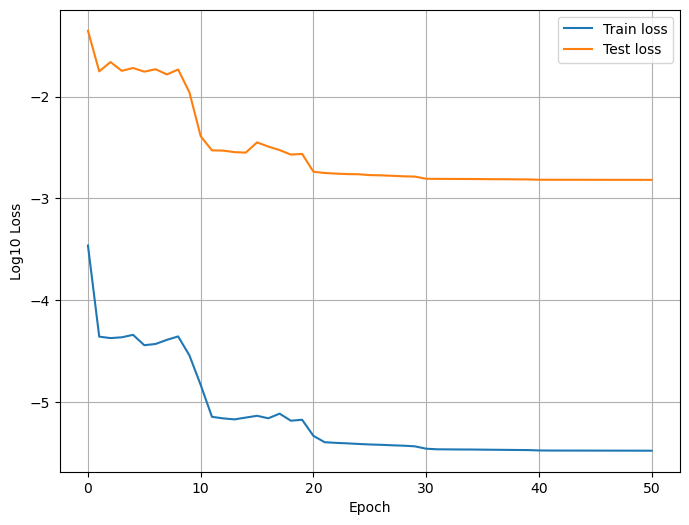

In [ ]:
print(f"Epoch [{epoch:03d}/{configs['epochs']-1}] in {stop_train-start_train:.2f}s with LR {scheduler.get_last_lr()[0]:.2e}: \tTrain loss {train_loss:.4e} \t- Test loss {test_loss:.4e} \t- Test Error {relative_error:.2f}% \t- Median Test Error {torch.median(median_error).item():.4f}%")

plt.figure(figsize=(8,6))
plt.plot([np.log10(x) for x in train_loss_hist], label='Train loss')
plt.plot([np.log10(x) for x in test_loss_hist], label='Test loss')
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.xlabel('Epoch')
plt.ylabel('Log10 Loss')
plt.legend()
plt.grid()
